In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
from PIL import Image

dataset_path = "FaceShape Dataset/training_set"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        path = os.path.join(root, file)

        try:
            with Image.open(path) as img:
                img.load()

        except Exception as e:

            print("Corrupted:", path)

            try:
                os.remove(path)
                print("Deleted:", path)

            except PermissionError:
                print("Skipped (file in use):", path)

In [23]:
BATCH_SIZE = 64
EPOCHS = 60
LR = 0.0001
NUM_CLASSES = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
transforms.RandomAffine(
    degrees=10,
    translate=(0.05,0.05)
)

RandomAffine(degrees=[-10.0, 10.0], translate=(0.05, 0.05))

In [25]:
train_dataset = datasets.ImageFolder(
    "FaceShape Dataset/training_set",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "FaceShape Dataset/testing_set",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.classes
print(class_names)

['Heart', 'Oblong', 'Oval', 'Round', 'Square']


In [26]:
model = models.efficientnet_b0(pretrained=True)

num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(num_features, NUM_CLASSES)

model = model.to(DEVICE)

d:\latihan\Face shape\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\latihan\Face shape\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

In [ ]:
best_acc = 0

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")


    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "face_shape_model.pth"
        )

        print("Model saved!")

Epoch 1/60
Train Loss: 1.4908
Val Accuracy: 0.4510
Model saved!
Epoch 2/60
Train Loss: 1.1907
Val Accuracy: 0.5650
Model saved!
Epoch 3/60
Train Loss: 0.9275
Val Accuracy: 0.6260
Model saved!
Epoch 4/60
Train Loss: 0.7188
Val Accuracy: 0.6810
Model saved!
Epoch 5/60
Train Loss: 0.5613
Val Accuracy: 0.7000
Model saved!
Epoch 6/60
Train Loss: 0.4505
Val Accuracy: 0.7350
Model saved!
Epoch 7/60
Train Loss: 0.3570
Val Accuracy: 0.7560
Model saved!
Epoch 8/60
Train Loss: 0.2796
Val Accuracy: 0.7640
Model saved!
Epoch 9/60
Train Loss: 0.2372
Val Accuracy: 0.7730
Model saved!
Epoch 10/60
Train Loss: 0.2073
Val Accuracy: 0.7770
Model saved!
Epoch 11/60
Train Loss: 0.1790
Val Accuracy: 0.7830
Model saved!
Epoch 12/60
Train Loss: 0.1506
Val Accuracy: 0.7820
Epoch 13/60
Train Loss: 0.1291
Val Accuracy: 0.7840
Model saved!
Epoch 14/60
Train Loss: 0.1024
Val Accuracy: 0.7970
Model saved!
Epoch 15/60
Train Loss: 0.1123
Val Accuracy: 0.7840
Epoch 16/60
Train Loss: 0.1085
Val Accuracy: 0.7790
Epoch 17

In [ ]:
import torch

MODEL_PATH = "face_shape_model.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [ ]:
model.load_state_dict(torch.load("face_shape_model.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [36]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

In [37]:
cm = confusion_matrix(all_labels, all_preds)

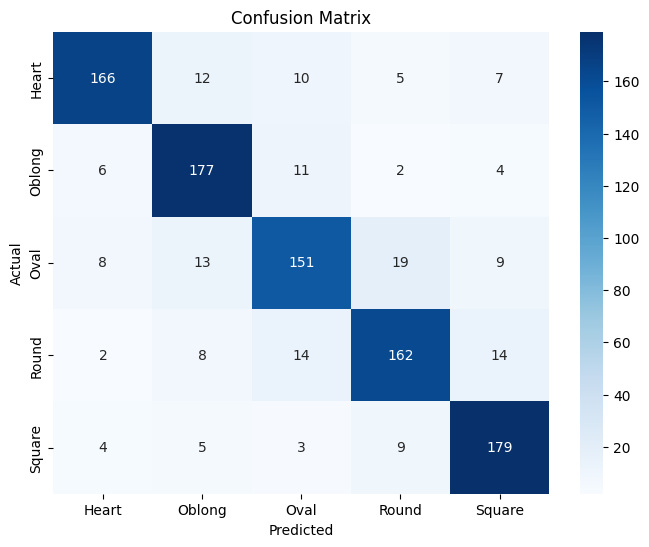

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       Heart       0.89      0.83      0.86       200
      Oblong       0.82      0.89      0.85       200
        Oval       0.80      0.76      0.78       200
       Round       0.82      0.81      0.82       200
      Square       0.84      0.90      0.87       200

    accuracy                           0.83      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.84      0.83      0.83      1000

